Mounted at /content/drive
Train shape: (320, 80)
Val shape: (80, 80)
Test shape: (100, 80)
=== KNN Metrics ===
Train Acc: 0.81875
Val Acc:   0.7
Test Acc:  0.69

Classification report (Test set):

               precision    recall  f1-score   support

     bollypop       0.57      0.85      0.68        20
     carnatic       0.94      0.75      0.83        20
       ghazal       0.80      1.00      0.89        20
semiclassical       0.55      0.55      0.55        20
         sufi       0.67      0.30      0.41        20

     accuracy                           0.69       100
    macro avg       0.70      0.69      0.67       100
 weighted avg       0.70      0.69      0.67       100



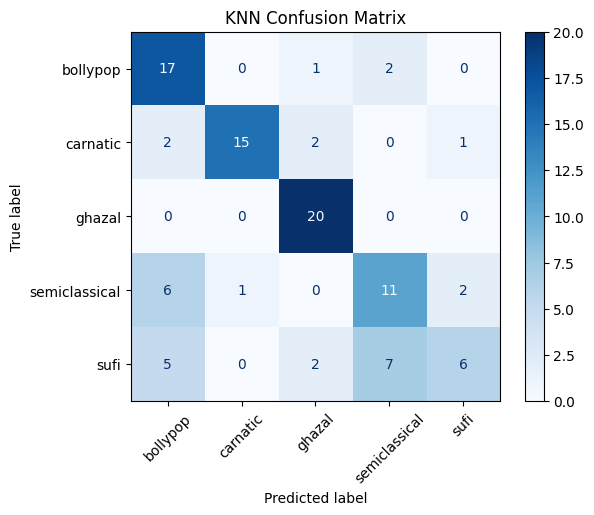

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.2294 - loss: 1.8792 - val_accuracy: 0.4125 - val_loss: 1.3988
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3784 - loss: 1.5019 - val_accuracy: 0.6250 - val_loss: 1.2003
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5645 - loss: 1.2121 - val_accuracy: 0.6750 - val_loss: 1.0697
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5946 - loss: 1.0495 - val_accuracy: 0.6875 - val_loss: 0.9742
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6461 - loss: 0.9894 - val_accuracy: 0.7125 - val_loss: 0.8982
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6852 - loss: 0.8274 - val_accuracy: 0.7125 - val_loss: 0.8296
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7120 - loss: 0.8024 - val_accuracy: 0.7000 - val_loss: 0.7713
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7518 - loss: 0.6751 - val_accuracy: 0.

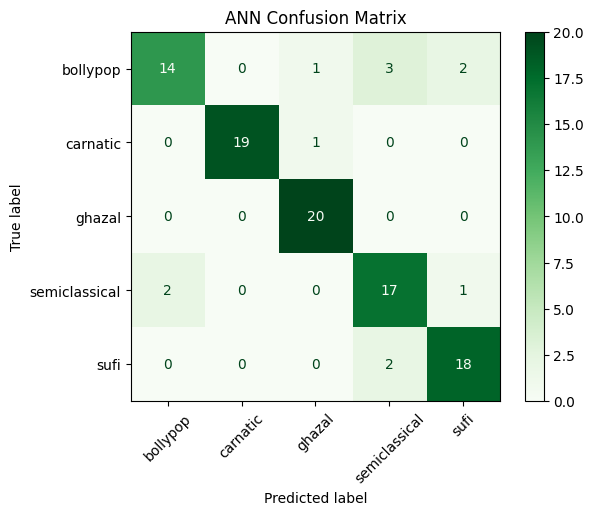

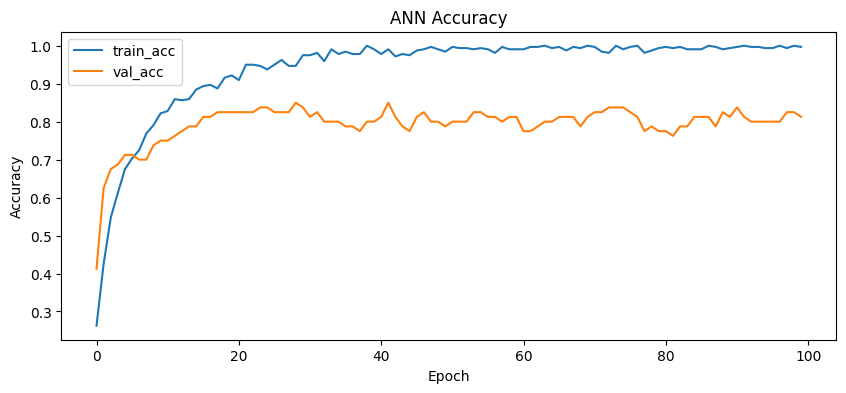

✅ Models, scaler, and encoder saved successfully!


In [2]:
# --- STEP 1: Imports ---
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
import joblib
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# --- STEP 2: Paths ---
TRAIN_DIR = Path("/content/drive/MyDrive/mgc_split/train")
TEST_DIR  = Path("/content/drive/MyDrive/mgc_split/test")

# --- STEP 3: Parameters ---
SAMPLE_RATE = 22050
N_MFCC = 40            # number of MFCC coefficients
DURATION = 45          # seconds per track
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

# --- STEP 4: Feature extraction ---
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
    # pad or truncate to fixed length
    if len(y) < SAMPLES_PER_TRACK:
        y = np.pad(y, (0, SAMPLES_PER_TRACK - len(y)))
    else:
        y = y[:SAMPLES_PER_TRACK]
    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=2048, hop_length=512)
    # Use mean + std over time axis to capture both average and variation
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std  = np.std(mfcc, axis=1)
    features = np.concatenate([mfcc_mean, mfcc_std])
    return features

def load_dataset(folder_path):
    X, y = [], []
    for class_dir in folder_path.iterdir():
        if class_dir.is_dir():
            label = class_dir.name
            for file in class_dir.glob("*.mp3"):
                feat = extract_features(file)
                X.append(feat)
                y.append(label)
            for file in class_dir.glob("*.wav"):
                feat = extract_features(file)
                X.append(feat)
                y.append(label)
    return np.array(X), np.array(y)

# --- STEP 5: Load datasets ---
X_train, y_train = load_dataset(TRAIN_DIR)
X_test, y_test   = load_dataset(TEST_DIR)

# Encode labels
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

# Split train into train + validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train_enc, test_size=0.2, random_state=42, stratify=y_train_enc
)

# Normalize features
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train shape:", X_train_final.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

# --- STEP 6: KNN Model ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_final, y_train_final)

y_train_knn = knn.predict(X_train_final)
y_val_knn   = knn.predict(X_val)
y_test_knn  = knn.predict(X_test)

print("=== KNN Metrics ===")
print("Train Acc:", accuracy_score(y_train_final, y_train_knn))
print("Val Acc:  ", accuracy_score(y_val, y_val_knn))
print("Test Acc: ", accuracy_score(y_test_enc, y_test_knn))
print("\nClassification report (Test set):\n")
print(classification_report(y_test_enc, y_test_knn, target_names=encoder.classes_))

# --- Confusion Matrix for KNN ---
cm_knn = confusion_matrix(y_test_enc, y_test_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=encoder.classes_)
disp_knn.plot(cmap="Blues", xticks_rotation=45)
plt.title("KNN Confusion Matrix")
plt.show()

# --- STEP 7: ANN Model ---
model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(X_train_final.shape[1],)),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(len(encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# --- STEP 8: ANN Evaluation ---
y_train_ann = np.argmax(model.predict(X_train_final), axis=1)
y_val_ann   = np.argmax(model.predict(X_val), axis=1)
y_test_ann  = np.argmax(model.predict(X_test), axis=1)

print("=== ANN Metrics ===")
print("Train Acc:", accuracy_score(y_train_final, y_train_ann))
print("Val Acc:  ", accuracy_score(y_val, y_val_ann))
print("Test Acc: ", accuracy_score(y_test_enc, y_test_ann))
print("\nClassification report (Test set):\n")
print(classification_report(y_test_enc, y_test_ann, target_names=encoder.classes_))

# --- Confusion Matrix for ANN ---
cm_ann = confusion_matrix(y_test_enc, y_test_ann)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=encoder.classes_)
disp_ann.plot(cmap="Greens", xticks_rotation=45)
plt.title("ANN Confusion Matrix")
plt.show()

# --- STEP 9: Plot Accuracy ---
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# --- STEP 10: Save Models ---
os.makedirs("/content/drive/MyDrive/saved_models", exist_ok=True)

# Save KNN model with joblib
joblib.dump(knn, "/content/drive/MyDrive/saved_models/knn_model.pkl")

# Save ANN model
model.save("/content/drive/MyDrive/saved_models/ann_model.h5")

# Save scaler and label encoder (needed for preprocessing later)
joblib.dump(scaler, "/content/drive/MyDrive/saved_models/scaler.pkl")
joblib.dump(encoder, "/content/drive/MyDrive/saved_models/label_encoder.pkl")

print("✅ Models, scaler, and encoder saved successfully!")



In [3]:
# --- STEP 11: Load Models Later ---
knn_loaded = joblib.load("/content/drive/MyDrive/saved_models/knn_model.pkl")
ann_loaded = keras.models.load_model("/content/drive/MyDrive/saved_models/ann_model.h5")
scaler_loaded = joblib.load("/content/drive/MyDrive/saved_models/scaler.pkl")
encoder_loaded = joblib.load("/content/drive/MyDrive/saved_models/label_encoder.pkl")

print("✅ Models loaded successfully!")

# --- STEP 12: Prediction Functions with Confidence Scores ---
def predict_genre_knn(file_path):
    feat = extract_features(file_path).reshape(1, -1)
    feat = scaler_loaded.transform(feat)
    probs = knn_loaded.predict_proba(feat)[0]   # probability for each class
    pred_idx = np.argmax(probs)
    pred_class = encoder_loaded.inverse_transform([pred_idx])[0]

    print("\n--- KNN Confidence Scores ---")
    for cls, p in zip(encoder_loaded.classes_, probs):
        print(f"{cls}: {p:.4f}")

    return pred_class


def predict_genre_ann(file_path):
    feat = extract_features(file_path).reshape(1, -1)
    feat = scaler_loaded.transform(feat)
    probs = ann_loaded.predict(feat)[0]   # probability for each class
    pred_idx = np.argmax(probs)
    pred_class = encoder_loaded.inverse_transform([pred_idx])[0]

    print("\n--- ANN Confidence Scores ---")
    for cls, p in zip(encoder_loaded.classes_, probs):
        print(f"{cls}: {p:.4f}")

    return pred_class

# --- Example Usage ---
# file_path = "/content/drive/MyDrive/mgc_split/test/Classical/sample1.mp3"
# print("Predicted (KNN):", predict_genre_knn(file_path))
# print("Predicted (ANN):", predict_genre_ann(file_path))


✅ Models loaded successfully!


In [4]:
# --- Example Usage ---
file_path = "/content/scl10.mp3"
print("Predicted (KNN):", predict_genre_knn(file_path))
print("Predicted (ANN):", predict_genre_ann(file_path))



--- KNN Confidence Scores ---
bollypop: 0.0000
carnatic: 0.2000
ghazal: 0.0000
semiclassical: 0.6000
sufi: 0.2000
Predicted (KNN): semiclassical
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step

--- ANN Confidence Scores ---
bollypop: 0.0003
carnatic: 0.0000
ghazal: 0.0000
semiclassical: 0.9989
sufi: 0.0009
Predicted (ANN): semiclassical
